In [2]:
import os
import torch

print("cwd:", os.getcwd())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

cwd: /content
cuda available: False


In [10]:
%env GITHUB_TOKEN=YOUR_GITHUB_TOKEN

env: GITHUB_TOKEN=YOUR_GITHUB_TOKEN


In [ ]:
%env WANDB_API_KEY=YOUR_WANDB_KEY
%env WANDB_ENTITY=AML_group6
%env WANDB_PROJECT=AML_Deep_ensembles

In [4]:
!git config --global user.email ""
!git config --global user.name ""

In [5]:
%cd /content
!rm -rf /content/AML_Deep_ensembles
!git clone https://$GITHUB_TOKEN@github.com/dcs321/AML_Deep_ensembles.git
%cd /content/AML_Deep_ensembles

/content
Cloning into 'AML_Deep_ensembles'...
remote: Enumerating objects: 288, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 288 (delta 2), reused 7 (delta 1), pack-reused 273 (from 1)
Receiving objects: 100% (288/288), 121.95 MiB | 28.65 MiB/s, done.
Resolving deltas: 100% (54/54), done.
Updating files: 100% (169/169), done.
/content/AML_Deep_ensembles


In [6]:
!pip install -r requirements.txt

In [7]:
!mkdir -p datasets/classification
%cd datasets/classification

!wget -O notMNIST_small.tar.gz http://yaroslavvb.com/upload/notMNIST/notMNIST_small.tar.gz && \
  tar -xzf notMNIST_small.tar.gz


%cd /content/AML_Deep_ensembles
!pwd
!ls

/content/AML_Deep_ensembles/datasets/classification
--2026-03-18 20:19:55--  http://yaroslavvb.com/upload/notMNIST/notMNIST_small.tar.gz
Resolving yaroslavvb.com (yaroslavvb.com)... 129.121.4.193
Connecting to yaroslavvb.com (yaroslavvb.com)|129.121.4.193|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8458043 (8.1M) [application/x-gzip]
Saving to: ‘notMNIST_small.tar.gz’

notMNIST_small.tar. 100%[===================>]   8.07M  --.-KB/s    in 0.04s   

2026-03-18 20:19:56 (198 MB/s) - ‘notMNIST_small.tar.gz’ saved [8458043/8458043]

/content/AML_Deep_ensembles
/content/AML_Deep_ensembles
AML_base_notebook.ipynb
augmentation.py
data.py
datasets
deep_esembles_vs_mc_dropout_classification_plot.ipynb
evaluation.py
models
models.py
plots
plotting.py
README.md
requirements.txt
run.py
ToyData_MSE_Regression.ipynb
training.py
utils.py


In [8]:
# Test loader
from data import load_notmnist

notmnist_loader = load_notmnist()

batch_x, batch_y = next(iter(notmnist_loader))

print("batch_x shape:", batch_x.shape)
print("batch_y shape:", batch_y.shape)
print("min pixel:", batch_x.min().item())
print("max pixel:", batch_x.max().item())
print("first 10 labels:", batch_y[:10])

Removed 2 corrupted images from NotMNIST
batch_x shape: torch.Size([100, 1, 28, 28])
batch_y shape: torch.Size([100])
min pixel: 0.0
max pixel: 1.0
first 10 labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


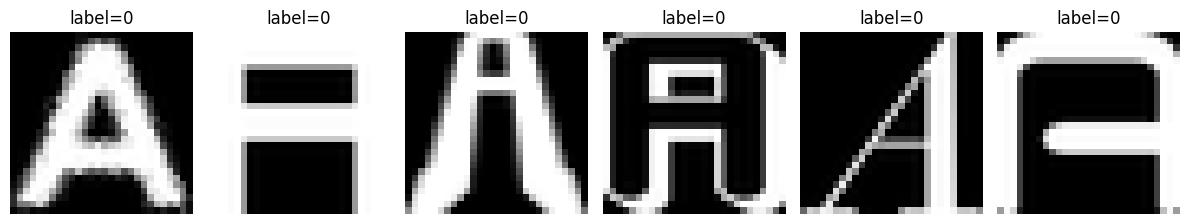

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    axes[i].imshow(batch_x[i].squeeze(), cmap="gray")
    axes[i].set_title(f"label={batch_y[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import torch
from data import load_mnist, load_notmnist
from utils import compute_entropy_comparison_results
from plotting import plot_entropy_comparison

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


_, _, mnist_test_loader = load_mnist(with_validation_set=False)
notmnist_loader = load_notmnist()

experiment_results = compute_entropy_comparison_results(
    mnist_test_loader=mnist_test_loader,
    notmnist_loader=notmnist_loader,
    device=device,
    ensemble_sizes=(1, 5, 10),
)

plot_entropy_comparison(
    experiment_results,
    ensemble_sizes=(1, 5, 10),
    save_path="plots/figure3_style_partial_replication.png",
)

In [ ]:
for method in ["ensemble", "ensemble_random", "ensemble_adversarial", "mc_dropout"]:
    for M in [1, 5, 10]:
        r = experiment_results[(method, M)]
        print(
            f"{method}, M={M} | "
            f"MNIST mean entropy = {r['mnist_mean']:.4f} | "
            f"NotMNIST mean entropy = {r['notmnist_mean']:.4f}"
        )

In [ ]:
from utils import compute_confidence_comparison_results
from plotting import plot_accuracy_vs_confidence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_, _, mnist_test_loader = load_mnist(with_validation_set=False)
notmnist_loader = load_notmnist()

confidence_results = compute_confidence_comparison_results(
    mnist_test_loader=mnist_test_loader,
    notmnist_loader=notmnist_loader,
    device=device,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    ensemble_size=10,   # closest to the paper final comparison
)

plot_accuracy_vs_confidence(
    confidence_results,
    save_path="plots/figure6_accuracy_vs_confidence.png",
)

In [ ]:
confidence_results_m5 = compute_confidence_comparison_results(
    mnist_test_loader=mnist_test_loader,
    notmnist_loader=notmnist_loader,
    device=device,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    ensemble_size=5,
)

plot_accuracy_vs_confidence(
    confidence_results_m5,
    save_path="plots/figure6_accuracy_vs_confidence_m5.png",
)

In [ ]:
confidence_results_m15 = compute_confidence_comparison_results(
    mnist_test_loader=mnist_test_loader,
    notmnist_loader=notmnist_loader,
    device=device,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    ensemble_size=15,
)

plot_accuracy_vs_confidence(
    confidence_results_m15,
    save_path="plots/figure6_accuracy_vs_confidence_m15.png",
)

In [ ]:
for method, result in confidence_results.items():
    print(method)
    for tau, acc in zip(result["thresholds"], result["accuracies"]):
        print(f"  tau={tau:.1f}: acc={acc:.2f}")